In [22]:
## Introduction: 
# This project analyzes a dataset of 911 emergency calls to identify patterns,trends, and insights using Python data analysis libraries.

In [3]:
# 911 Calls Data Analysis

## Student Name: Egbuchulam_Nnamdi
## Course: Module2_Assignment.ipynb
## Date:29/4/2026

In [ ]:
# Part A — Environment Setup 


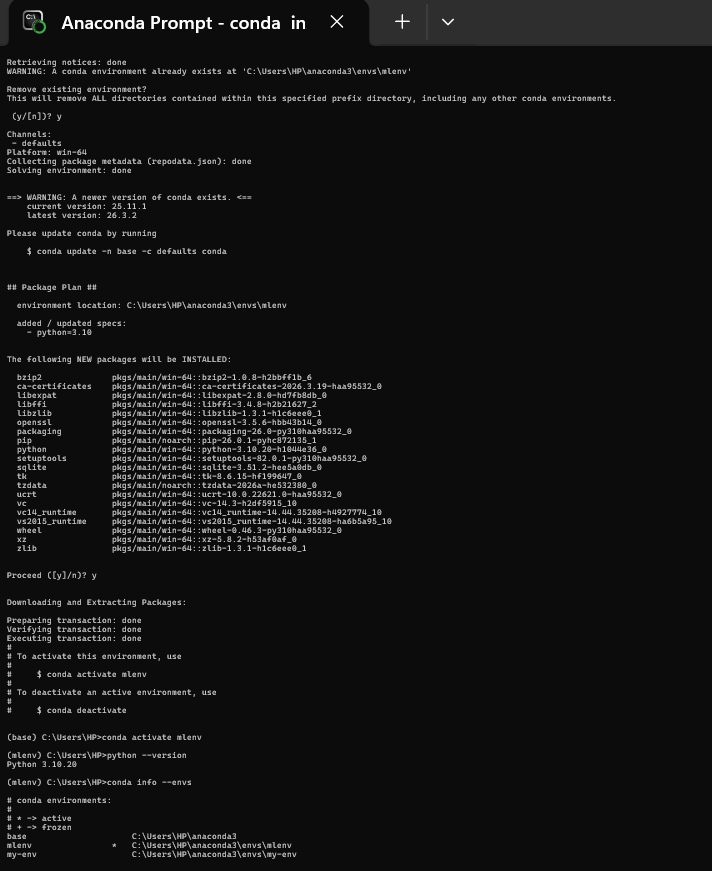

In [ ]:
##  Part B — Package Installation.

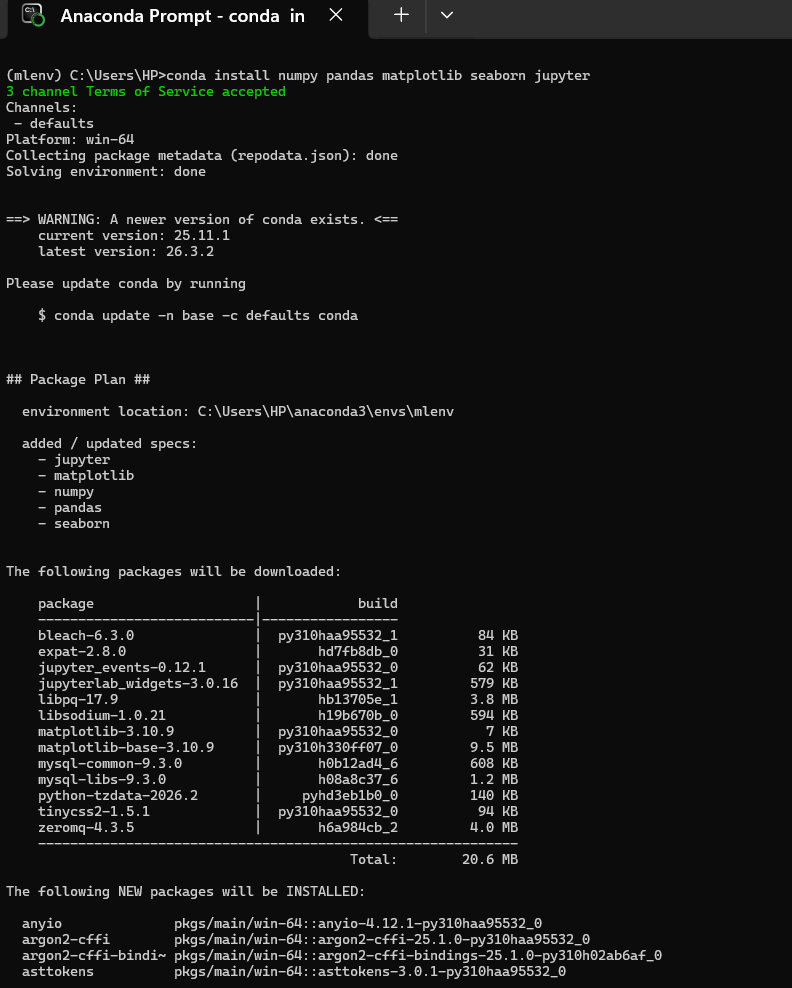

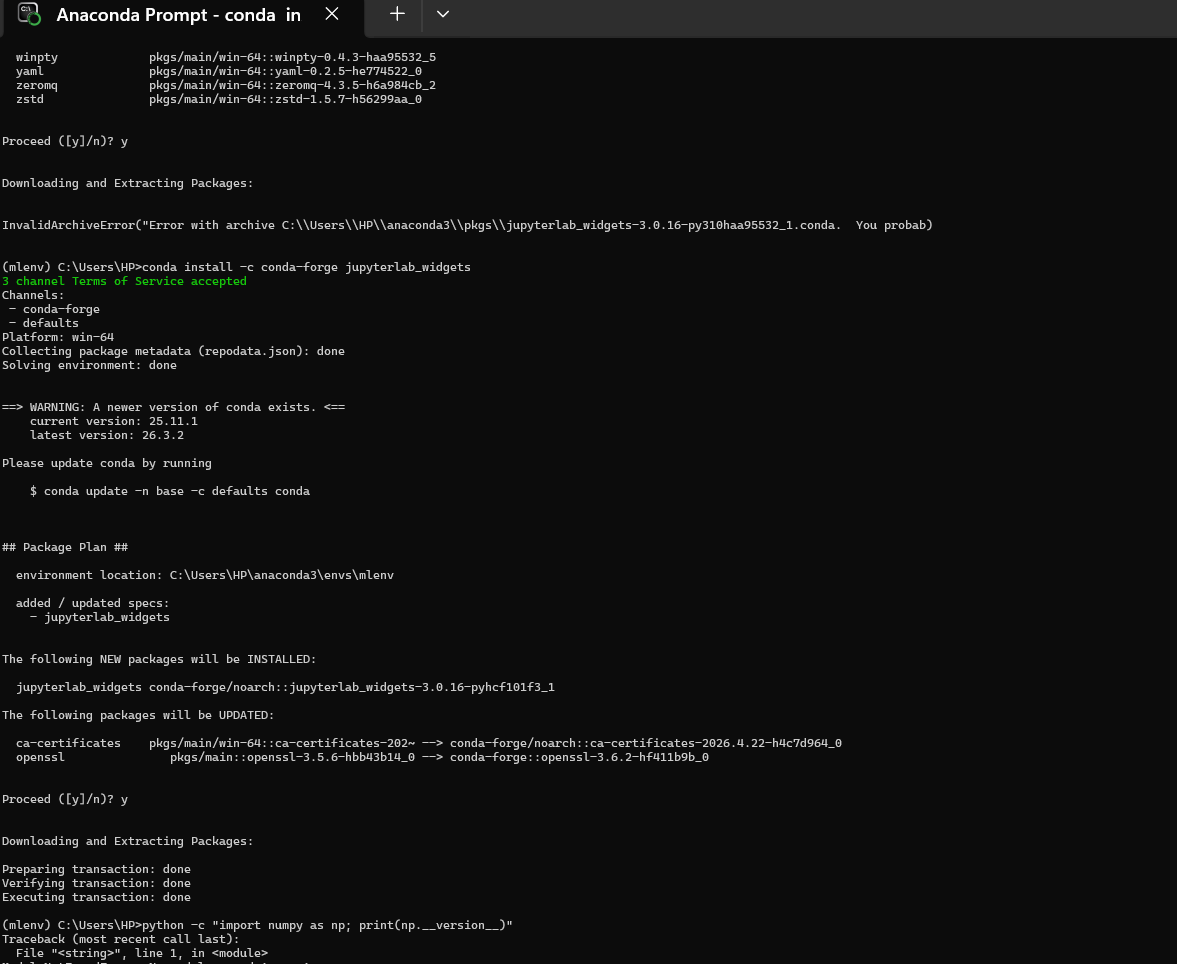

In [ ]:
## Part C — Coding Tasks

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

In [1]:
## My file is saved as 911.csv.csv instead of 911.csv
import pandas as pd
df = pd.read_csv("'911.csv'.csv")
print("Successfully loaded!")
df.head()
print(df.shape)
print(df.columns.tolist())

Successfully loaded!
(663522, 9)
['lat', 'lng', 'desc', 'zip', 'title', 'timeStamp', 'twp', 'addr', 'e']


In [ ]:
## Observation prompt

# The dataset was successfully loaded into a Pandas DataFrame containing thousands of emergency call records and multiple descriptive columns. 
# The shape output confirms the number of rows and columns in the dataset, while the column list provides an overview of available features such as location, timestamp, township, and emergency type.
# Inspecting the structure early helps ensure the dataset loaded correctly and prevents errors during later analysis.

In [2]:
# Display the first 10 rows and the last 5 rows of the dataset.
display(df.head(10))
display(df.tail(5))

,lat,lng,desc,zip,title,timeStamp,twp,addr,e
0,40.297876,-75.581294,REINDEER CT & DEAD END; NEW HANOVER; Station ...,19525.0,EMS: BACK PAINS/INJURY,2015-12-10 17:10:52,NEW HANOVER,REINDEER CT & DEAD END,1
1,40.258061,-75.264680,BRIAR PATH & WHITEMARSH LN; HATFIELD TOWNSHIP...,19446.0,EMS: DIABETIC EMERGENCY,2015-12-10 17:29:21,HATFIELD TOWNSHIP,BRIAR PATH & WHITEMARSH LN,1
2,40.121182,-75.351975,HAWS AVE; NORRISTOWN; 2015-12-10 @ 14:39:21-St...,19401.0,Fire: GAS-ODOR/LEAK,2015-12-10 14:39:21,NORRISTOWN,HAWS AVE,1
3,40.116153,-75.343513,AIRY ST & SWEDE ST; NORRISTOWN; Station 308A;...,19401.0,EMS: CARDIAC EMERGENCY,2015-12-10 16:47:36,NORRISTOWN,AIRY ST & SWEDE ST,1
4,40.251492,-75.603350,CHERRYWOOD CT & DEAD END; LOWER POTTSGROVE; S...,NaN,EMS: DIZZINESS,2015-12-10 16:56:52,LOWER POTTSGROVE,CHERRYWOOD CT & DEAD END,1
5,40.253473,-75.283245,CANNON AVE & W 9TH ST; LANSDALE; Station 345;...,19446.0,EMS: HEAD INJURY,2015-12-10 15:39:04,LANSDALE,CANNON AVE & W 9TH ST,1
6,40.182111,-75.127795,LAUREL AVE & OAKDALE AVE; HORSHAM; Station 35...,19044.0,EMS: NAUSEA/VOMITING,2015-12-10 16:46:48,HORSHAM,LAUREL AVE & OAKDALE AVE,1
7,40.217286,-75.405182,COLLEGEVILLE RD & LYWISKI RD; SKIPPACK; Stati...,19426.0,EMS: RESPIRATORY EMERGENCY,2015-12-10 16:17:05,SKIPPACK,COLLEGEVILLE RD & LYWISKI RD,1
8,40.289027,-75.399590,MAIN ST & OLD SUMNEYTOWN PIKE; LOWER SALFORD;...,19438.0,EMS: SYNCOPAL EPISODE,2015-12-10 16:51:42,LOWER SALFORD,MAIN ST & OLD SUMNEYTOWN PIKE,1
9,40.102398,-75.291458,BLUEROUTE & RAMP I476 NB TO CHEMICAL RD; PLYM...,19462.0,Traffic: VEHICLE ACCIDENT -,2015-12-10 17:35:41,PLYMOUTH,BLUEROUTE & RAMP I476 NB TO CHEMICAL RD,1


,lat,lng,desc,zip,title,timeStamp,twp,addr,e
663517,40.157956,-75.348060,SUNSET AVE & WOODLAND AVE; EAST NORRITON; 2020...,19403.0,Traffic: VEHICLE ACCIDENT -,2020-07-29 15:46:51,EAST NORRITON,SUNSET AVE & WOODLAND AVE,1
663518,40.136306,-75.428697,EAGLEVILLE RD & BUNTING CIR; LOWER PROVIDENCE...,19403.0,EMS: GENERAL WEAKNESS,2020-07-29 15:52:19,LOWER PROVIDENCE,EAGLEVILLE RD & BUNTING CIR,1
663519,40.013779,-75.300835,HAVERFORD STATION RD; LOWER MERION; Station 3...,19041.0,EMS: VEHICLE ACCIDENT,2020-07-29 15:52:52,LOWER MERION,HAVERFORD STATION RD,1
663520,40.121603,-75.351437,MARSHALL ST & HAWS AVE; NORRISTOWN; 2020-07-29...,19401.0,Fire: BUILDING FIRE,2020-07-29 15:54:08,NORRISTOWN,MARSHALL ST & HAWS AVE,1
663521,40.015046,-75.299674,HAVERFORD STATION RD & W MONTGOMERY AVE; LOWER...,19041.0,Traffic: VEHICLE ACCIDENT -,2020-07-29 15:52:46,LOWER MERION,HAVERFORD STATION RD & W MONTGOMERY AVE,1


In [3]:
# Display dataset information
df.info()

# Display statistical summary
df.describe()

# Check missing values
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 663522 entries, 0 to 663521
Data columns (total 9 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   lat        663522 non-null  float64
 1   lng        663522 non-null  float64
 2   desc       663522 non-null  object 
 3   zip        583323 non-null  float64
 4   title      663522 non-null  object 
 5   timeStamp  663522 non-null  object 
 6   twp        663229 non-null  object 
 7   addr       663522 non-null  object 
 8   e          663522 non-null  int64  
dtypes: float64(3), int64(1), object(5)
memory usage: 45.6+ MB
lat              0
lng              0
desc             0
zip          80199
title            0
timeStamp        0
twp            293
addr             0
e                0
dtype: int64


In [8]:
# Create department column
df['dept'] = df['title'].apply(lambda x: x.split(':')[0].strip())

# Create reason column
df['reason'] = df['title'].apply(lambda x: x.split(':')[1].strip())

In [15]:
# Created two new columns called dept and reason

df['dept'] = df['title'].apply(lambda x: x.split(':')[0].strip())
df['reason'] = df['title'].apply(lambda x: x.split(':', 1)[1].strip())

df[['title', 'dept', 'reason']].head()

,title,dept,reason
0,EMS: BACK PAINS/INJURY,EMS,BACK PAINS/INJURY
1,EMS: DIABETIC EMERGENCY,EMS,DIABETIC EMERGENCY
2,Fire: GAS-ODOR/LEAK,Fire,GAS-ODOR/LEAK
3,EMS: CARDIAC EMERGENCY,EMS,CARDIAC EMERGENCY
4,EMS: DIZZINESS,EMS,DIZZINESS


In [4]:
# Find top 5 townships by number of calls
top_5_twp = df['twp'].value_counts().head(5)

# Print results
print(top_5_twp)

twp
LOWER MERION    55490
ABINGTON        39947
NORRISTOWN      37633
UPPER MERION    36010
CHELTENHAM      30574
Name: count, dtype: int64


In [ ]:
## The analysis shows that a small number of townships account for a large proportion of total emergency calls. 
# LOWER MERION appears to have the highest call volume, followed by townships such as ABINGTON and NORRISTOWN. 
# This likely reflects differences in population density, commercial activity, and traffic levels across the county. 
# Identifying high-call regions is important for emergency resource planning and public safety management.

In [9]:
# Filter only EMS calls
ems_df = df[df['dept'] == 'EMS']

# Count number of EMS calls
print(len(ems_df))

332692


In [ ]:
# Observation

## EMS calls represent the largest category of emergency incidents in the dataset. 
#This indicates that medical emergencies occur much more frequently than fire or traffic-related incidents. 
# The high volume of EMS calls highlights the importance of medical response services in emergency management operations.

In [10]:
# Check how many ZIP codes are missing
print(df['zip'].isnull().sum())

# Fill missing ZIP values with 0
df['zip'] = df['zip'].fillna(0)

# Confirm no missing values remain
print(df['zip'].isnull().sum())


80199
0


In [ ]:
# The zip column originally contained 80,199 missing values. 
# These missing entries were replaced with 0 using the fillna() method as part of the data cleaning process. 
# After cleaning, a second null-value check confirmed that no missing values remained in the zip column.

In [ ]:
# in Summary
## The dataset contains emergency call records from different departments, locations, and time periods. 
# EMS had the highest number of calls, while LOWER MERION was the most active township in the dataset. 
# One surprising finding was the very large number of missing ZIP code values that required cleaning before analysis.

In [ ]:
### NumPy: Numerical Analysis on 911 Data

In [11]:
# Extract latitude and longitude columns as NumPy arrays
lat_arr = df['lat'].to_numpy()
lng_arr = df['lng'].to_numpy()

# Print data types
print(type(lat_arr))
print(type(lng_arr))

# Print shapes
print(lat_arr.shape)
print(lng_arr.shape)

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
(663522,)
(663522,)


In [ ]:
#The latitude and longitude columns were successfully converted from Pandas Series into NumPy arrays. 
# Both arrays are one-dimensional and contain the same number of records as the dataset rows.
#NumPy arrays are useful for fast numerical computations and efficient mathematical analysis.

In [13]:
import numpy as np

In [14]:
# Calculate statistics for latitude column

mean_lat = np.mean(lat_arr)
std_lat  = np.std(lat_arr)
min_lat  = np.min(lat_arr)
max_lat  = np.max(lat_arr)
range_lat = max_lat - min_lat

# Print results
print("Mean:", mean_lat)
print("Standard Deviation:", std_lat)
print("Minimum:", min_lat)
print("Maximum:", max_lat)
print("Range:", range_lat)

Mean: 40.1581621399711
Standard Deviation: 0.22064127201581607
Minimum: 0.0
Maximum: 51.3353899
Range: 51.3353899


In [ ]:
# The latitude values show the geographic distribution of emergency calls across the region. 
# The mean provides the central location, while the standard deviation and range indicate how spread out the call locations are. 
# The minimum and maximum values help identify the geographic boundaries of the recorded incidents.

In [17]:
# Count calls from each department
dept_counts = df['dept'].value_counts()

# Print department counts
print(dept_counts)

# Convert counts to NumPy array
counts_arr = dept_counts.to_numpy()

# Print NumPy array
print(counts_arr)

# Calculate total calls
total_calls = counts_arr.sum()

print("Total Calls:", total_calls)

# Calculate percentage share
percentages = (counts_arr / total_calls) * 100

# Print percentage share
print("Percentage Share:")
print(percentages)

dept
EMS        332692
Traffic    230208
Fire       100622
Name: count, dtype: int64
[332692 230208 100622]
Total Calls: 663522
Percentage Share:
[50.14031185 34.69485563 15.16483251]


In [18]:
# Convert timeStamp column to datetime
df['timeStamp'] = pd.to_datetime(df['timeStamp'])

# Extract hour from each timestamp as NumPy array
hour_arr = df['timeStamp'].dt.hour.to_numpy()

# Count calls for each hour using NumPy
hour_counts = np.bincount(hour_arr)

# Print results
print(hour_arr)
print(hour_counts)

[17 17 14 ... 15 15 15]
[13863 11751 10653  9488  9265 11676 17219 26971 33380 35477 36577 38076
 40097 39797 40346 42263 42797 44119 37322 32442 28079 24659 20313 16892]


In [19]:
# Create boolean mask for daytime calls (08:00 to 18:00)
day_mask = (hour_arr >= 8) & (hour_arr <= 18)

# Count daytime calls
day_calls = day_mask.sum()

# Count nighttime calls
night_calls = (~day_mask).sum()

# Print results
print("Daytime Calls:", day_calls)
print("Nighttime Calls:", night_calls)

Daytime Calls: 430251
Nighttime Calls: 233271


In [ ]:
# Converting Pandas columns to NumPy arrays improves speed and efficiency for large numerical computations. 
# Use np.mean() when working directly with arrays for performance, and df['col'].mean() when handling labeled DataFrame data for convenience.

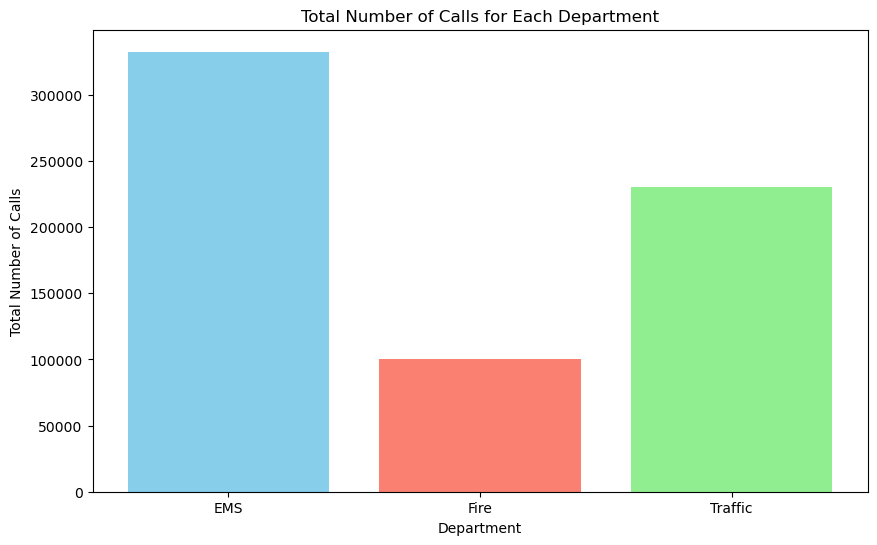

In [20]:
 # Matplotlib: Visualising the 911 Data

import pandas as pd
import matplotlib.pyplot as plt

# Load the 911 dataset
df = pd.read_csv(r"C:\Users\HP\OneDrive\Desktop\911_Assignment\911.csv.csv")

# Extract department names from the title column
# Example: "EMS: BACK PAINS/INJURY" becomes "EMS"
df["Department"] = df["title"].str.split(":").str[0]

# Count total calls for each department
department_counts = df["Department"].value_counts()

# Keep only the required departments in a fixed order
departments = ["EMS", "Fire", "Traffic"]
call_totals = department_counts.loc[departments]

# Create the bar chart
plt.figure(figsize=(10, 6))

colors = ["skyblue", "salmon", "lightgreen"]

plt.bar(
    call_totals.index,
    call_totals.values,
    color=colors
)

plt.title("Total Number of Calls for Each Department")
plt.xlabel("Department")
plt.ylabel("Total Number of Calls")

plt.show()


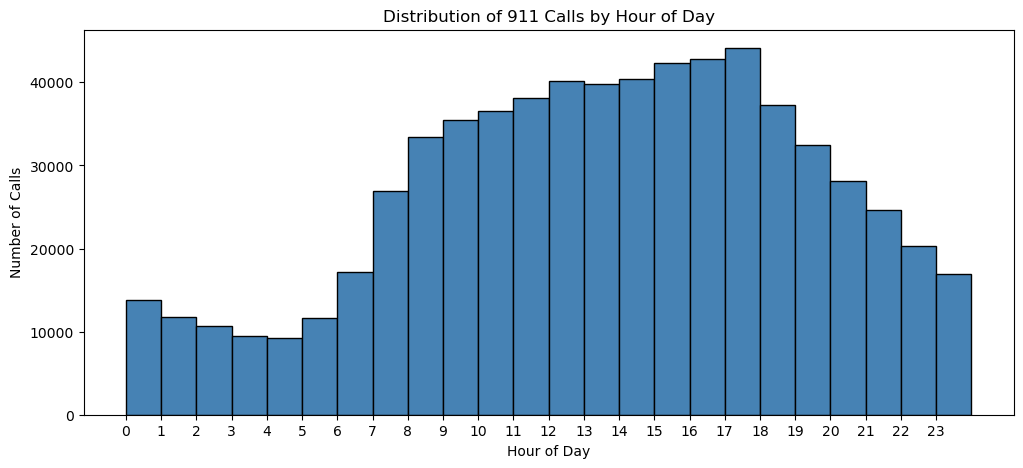

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv(r"C:\Users\HP\OneDrive\Desktop\911_Assignment\911.csv.csv")

# Convert the timeStamp column to datetime format
df["timeStamp"] = pd.to_datetime(df["timeStamp"])

# Extract the hour of day from the timestamp
df["Hour"] = df["timeStamp"].dt.hour

# Create the histogram
plt.figure(figsize=(12, 5))

plt.hist(
    df["Hour"],
    bins=24,
    range=(0, 24),
    color="steelblue",
    edgecolor="black"
)

plt.title("Distribution of 911 Calls by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Calls")

plt.xticks(range(0, 24))

plt.show()


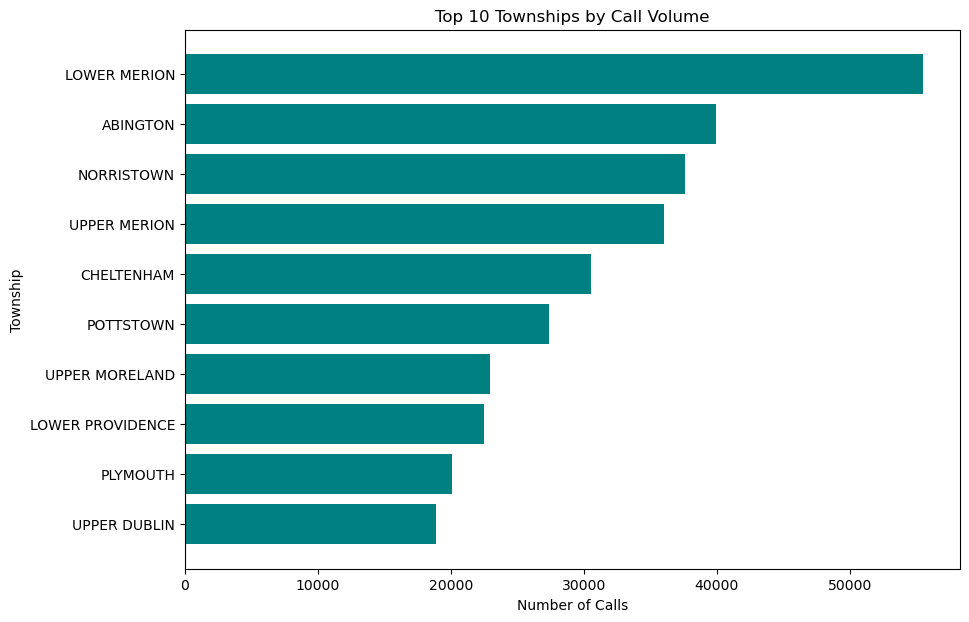

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv(r"C:\Users\HP\OneDrive\Desktop\911_Assignment\911.csv.csv")

# Count calls for each township and select the top 10
top_10_townships = df["twp"].value_counts().head(10)

# Sort so the highest value appears at the top of the horizontal bar chart
top_10_townships = top_10_townships.sort_values(ascending=True)

# Create the horizontal bar chart
plt.figure(figsize=(10, 7))

plt.barh(
    top_10_townships.index,
    top_10_townships.values,
    color="teal"
)

plt.title("Top 10 Townships by Call Volume")
plt.xlabel("Number of Calls")
plt.ylabel("Township")

plt.show()


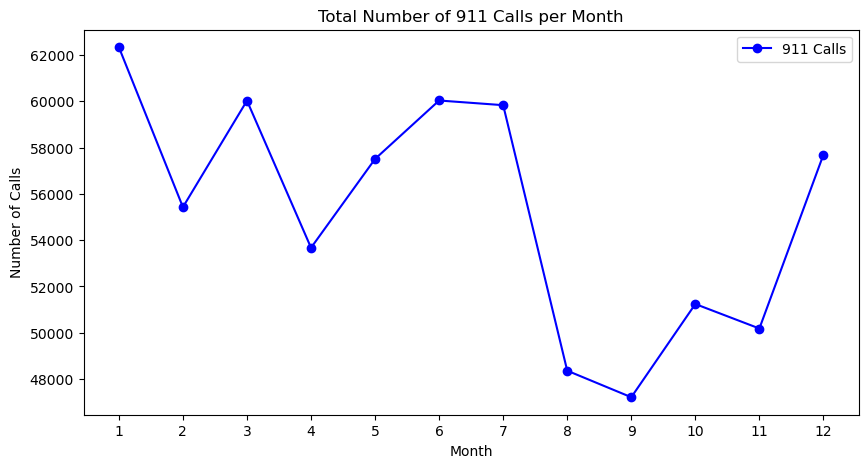

In [33]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv(r"C:\Users\HP\OneDrive\Desktop\911_Assignment\911.csv.csv")

# Convert timeStamp column to datetime format
df["timeStamp"] = pd.to_datetime(df["timeStamp"])

# Extract the month from the timeStamp column
df["Month"] = df["timeStamp"].dt.month

# Group by month and count the number of calls
monthly_calls = df.groupby("Month").size()

# Create the line chart
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_calls.index,
    monthly_calls.values,
    marker="o",
    color="blue",
    label="911 Calls"
)

plt.title("Total Number of 911 Calls per Month")
plt.xlabel("Month")
plt.ylabel("Number of Calls")
plt.xticks(range(1, 13))
plt.legend()

plt.show()


In [ ]:
# Department calls are highest for EMS, followed by Traffic and Fire. 
# Hourly calls peak in the late afternoon/early evening, likely due to commuting and daily activity.
# Monthly calls show mild seasonal variation, with busier warmer months.

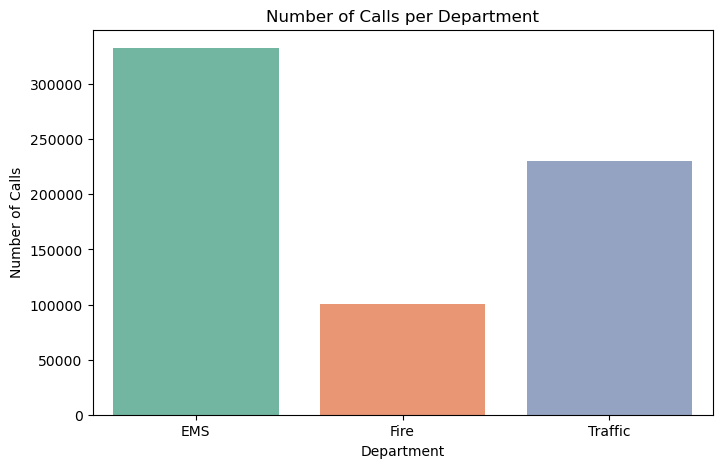

In [30]:
 # Seaborn: Statistical Visualisation

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv(r"C:\Users\HP\OneDrive\Desktop\911_Assignment\911.csv.csv")

# Extract department from the title column
df["Department"] = df["title"].str.split(":").str[0]

# Create countplot
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Department",
    hue="Department",
    palette="Set2",
    order=["EMS", "Fire", "Traffic"],
    hue_order=["EMS", "Fire", "Traffic"],
    legend=False
)

plt.title("Number of Calls per Department")
plt.xlabel("Department")
plt.ylabel("Number of Calls")

plt.show()



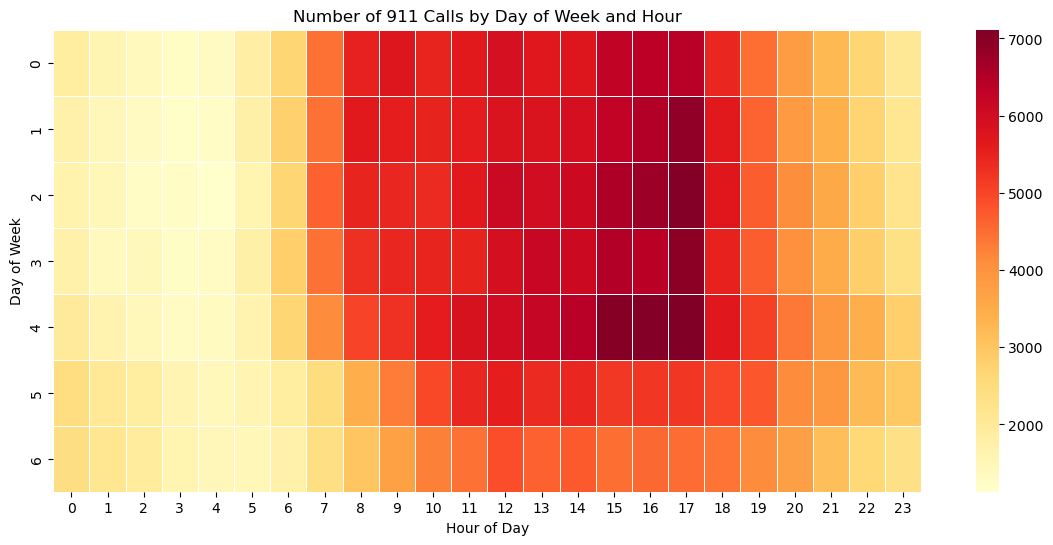

In [34]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv(r"C:\Users\HP\OneDrive\Desktop\911_Assignment\911.csv.csv")

# Convert timeStamp to datetime
df["timeStamp"] = pd.to_datetime(df["timeStamp"])

# Extract day of week and hour of day
df["DayOfWeek"] = df["timeStamp"].dt.dayofweek
df["Hour"] = df["timeStamp"].dt.hour

# Create pivot table: rows = day of week, columns = hour, values = number of calls
day_hour_pivot = df.pivot_table(
    index="DayOfWeek",
    columns="Hour",
    values="timeStamp",
    aggfunc="count"
)

# Create heatmap
plt.figure(figsize=(14, 6))

sns.heatmap(
    day_hour_pivot,
    cmap="YlOrRd",
    linewidths=0.5
)

plt.title("Number of 911 Calls by Day of Week and Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")

plt.show()


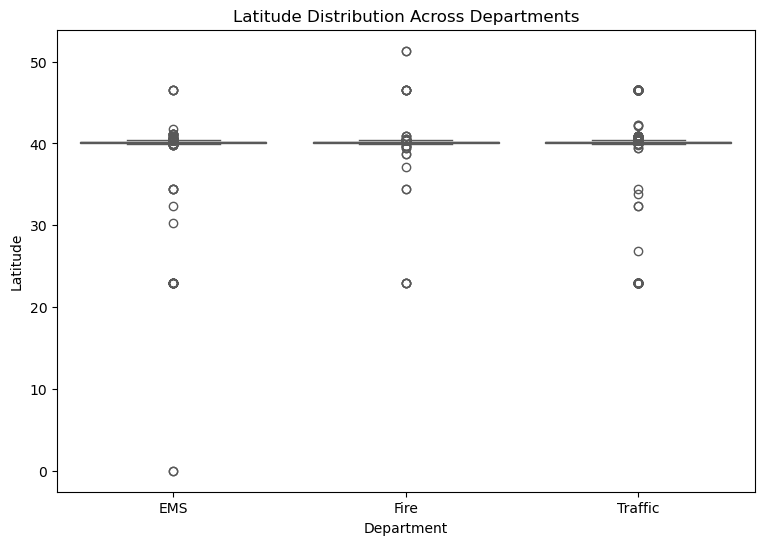

In [35]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv(r"C:\Users\HP\OneDrive\Desktop\911_Assignment\911.csv.csv")

# Extract department from the title column
df["Department"] = df["title"].str.split(":").str[0]

# Create boxplot comparing latitude values across departments
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df,
    x="Department",
    y="lat",
    hue="Department",
    palette="Set2",
    order=["EMS", "Fire", "Traffic"],
    hue_order=["EMS", "Fire", "Traffic"],
    legend=False
)

plt.title("Latitude Distribution Across Departments")
plt.xlabel("Department")
plt.ylabel("Latitude")

plt.show()


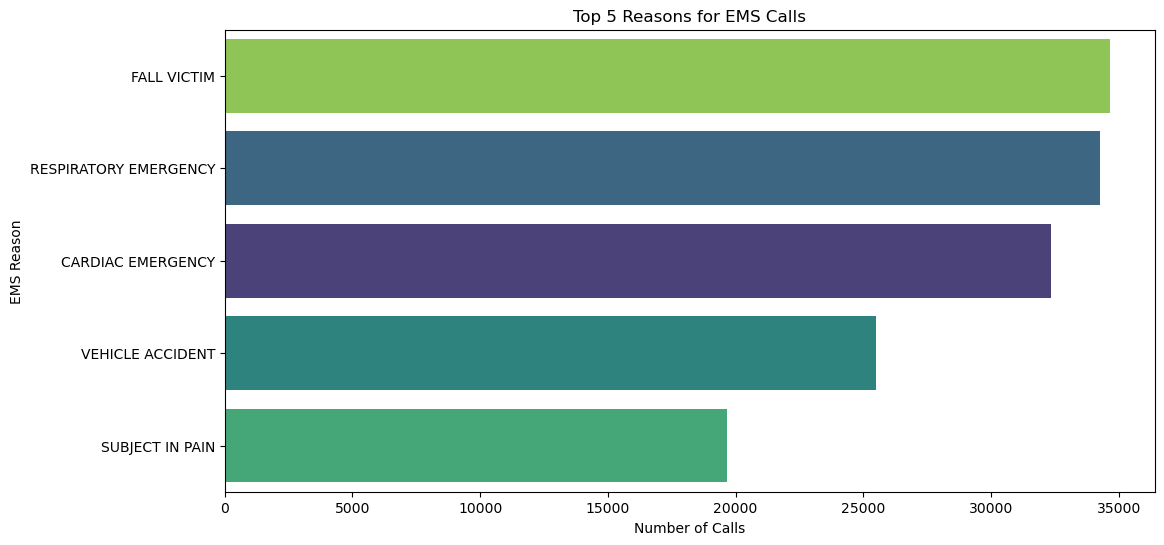

In [36]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv(r"C:\Users\HP\OneDrive\Desktop\911_Assignment\911.csv.csv")

# Extract department and reason from the title column
# Example: "EMS: BACK PAINS/INJURY"
df["Department"] = df["title"].str.split(":").str[0]
df["Reason"] = df["title"].str.split(":").str[1].str.strip()

# Filter the DataFrame for EMS calls only
ems_df = df[df["Department"] == "EMS"]

# Use value_counts() to identify the top 5 EMS reasons
top_5_ems_reasons = ems_df["Reason"].value_counts().head(5).index

# Filter EMS data to only those top 5 reasons
ems_top_5_df = ems_df[ems_df["Reason"].isin(top_5_ems_reasons)]

# Create countplot
plt.figure(figsize=(12, 6))

sns.countplot(
    data=ems_top_5_df,
    y="Reason",
    hue="Reason",
    order=top_5_ems_reasons,
    palette="viridis",
    legend=False
)

plt.title("Top 5 Reasons for EMS Calls")
plt.xlabel("Number of Calls")
plt.ylabel("EMS Reason")

plt.show()


In [ ]:
# The day-hour heatmap shows emergency calls are highest during busy daytime or early evening periods, especially on weekdays when travel, work, and public activity increase. 
# The fewest calls usually occur overnight, when most people are asleep and roads are quieter.
# Overnight patterns may reflect fewer accidents, reduced movement, and lower public activity.